In [7]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

print("✅ 所有库导入成功！")
print(f"PyTorch 版本: {torch.__version__}")
print(f"TorchVision 版本: {torchvision.__version__}")
print(f"NumPy 版本: {np.__version__}")
print("环境完全正常，可以开始作业！")

✅ 所有库导入成功！
PyTorch 版本: 2.12.0+cpu
TorchVision 版本: 0.27.0+cpu
NumPy 版本: 2.1.3
环境完全正常，可以开始作业！


2.1 理论计算题
1. 非线性激活函数的重要性：假设一个具有单隐藏层的多层感知机，输
入为 x，隐藏层没有激活函数（即线性激活），表达为 h = W1x + b1，
输出层为 o = W2h + b2 。请通过代数推导证明，该网络等价于一个单
层神经网络，并写出等价后的权重矩阵 W′ 和偏置向量 b
′ 。
2. 激活函数性质分析：写出 Sigmoid(x) 和 tanh(x) 的数学表达式，并推
导它们的导数 Sigmoid′(x) 和 tanh′(x) 与其函数自身的关系。

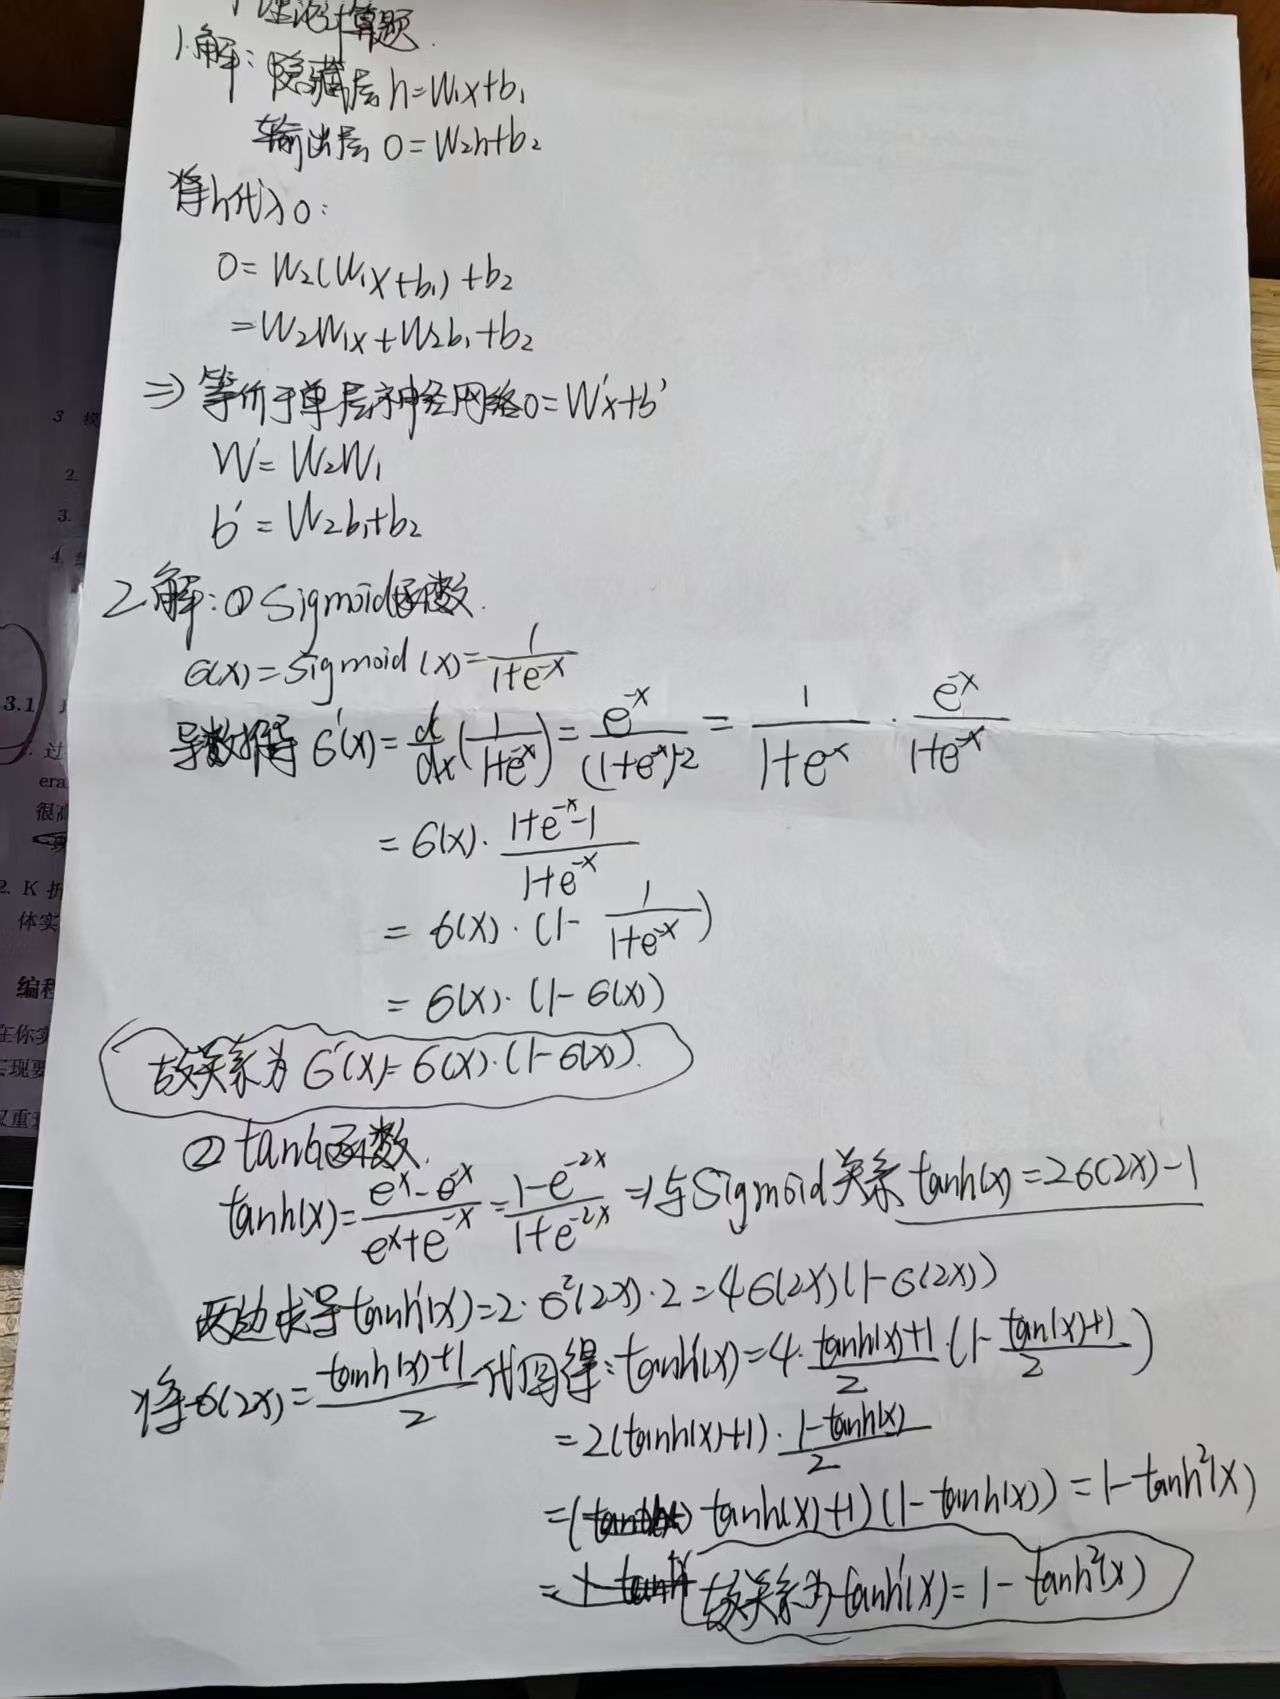

2.2 编程题
不使用深度学习框架的高级 API（仅使用 Tensor 基础算子如 torch.matmul
等），纯 NumPy 或 PyTorch 从零实现一个多分类（使用 Fashion-MNIST
数据集）的单隐藏层 MLP。
实现要求：
1. 手动初始化隐藏层参数 W1, b1 和输出层参数 W2, b2（提示：使用正态
分布随机初始化）。
2. 实现 ReLU 激活函数的前向传播：max(0, x) 。
3. 实现带有 Softmax 的交叉熵损失函数。
4. 编写训练循环，通过小批量随机梯度下降（Mini-batch SGD）手动更
新参数。

In [ ]:
# 2.2 多层感知机从零实现 
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # 解决 OpenMP 冲突

import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib
matplotlib.use('Agg')  # 非交互式后端
import matplotlib.pyplot as plt
import gc
import sys

print("="*50)
print("2.2 多层感知机从零实现")
print("="*50)

# 加载数据
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

# 添加错误处理
try:
    train_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=True, download=True, transform=transform
    )
    test_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=False, download=True, transform=transform
    )
    print("数据加载成功！")
except Exception as e:
    print(f"数据加载失败: {e}")
    sys.exit(1)

batch_size = 256
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")
print(f"输入维度: {28*28}")
print(f"输出类别数: 10")

class MLPFromScratch:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.W1 = torch.randn(input_size, hidden_size) * 0.01
        self.b1 = torch.zeros(hidden_size)
        self.W2 = torch.randn(hidden_size, output_size) * 0.01
        self.b2 = torch.zeros(output_size)
        self.lr = lr
        
    def relu(self, x):
        return torch.maximum(torch.tensor(0.0), x)
    
    def relu_derivative(self, x):
        return (x > 0).float()
    
    def softmax(self, x):
        exp_x = torch.exp(x - torch.max(x, dim=1, keepdim=True)[0])
        return exp_x / torch.sum(exp_x, dim=1, keepdim=True)
    
    def cross_entropy_with_softmax(self, logits, y):
        shifted_logits = logits - torch.max(logits, dim=1, keepdim=True)[0]
        exp_logits = torch.exp(shifted_logits)
        probs = exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)
        batch_size = logits.shape[0]
        loss = -torch.log(probs[range(batch_size), y] + 1e-10)
        return torch.mean(loss)
    
    def forward(self, X):
        self.z1 = torch.mm(X, self.W1) + self.b1
        self.h1 = self.relu(self.z1)
        self.z2 = torch.mm(self.h1, self.W2) + self.b2
        return self.z2
    
    def backward(self, X, y):
        batch_size = X.shape[0]
        probs = self.softmax(self.z2)
        probs[range(batch_size), y] -= 1
        d_z2 = probs / batch_size
        d_W2 = torch.mm(self.h1.T, d_z2)
        d_b2 = torch.sum(d_z2, dim=0)
        d_h1 = torch.mm(d_z2, self.W2.T)
        d_z1 = d_h1 * self.relu_derivative(self.z1)
        d_W1 = torch.mm(X.T, d_z1)
        d_b1 = torch.sum(d_z1, dim=0)
        
        self.W2 -= self.lr * d_W2
        self.b2 -= self.lr * d_b2
        self.W1 -= self.lr * d_W1
        self.b1 -= self.lr * d_b1
    
    def predict(self, X):
        logits = self.forward(X)
        return torch.argmax(logits, dim=1)
    
    def accuracy(self, X, y):
        pred = self.predict(X)
        return torch.mean((pred == y).float()).item()

# 训练
input_size = 28 * 28
hidden_size = 256
output_size = 10
lr = 0.1
epochs = 10

model = MLPFromScratch(input_size, hidden_size, output_size, lr)

print("\n开始训练...")
train_losses = []
train_accs = []
test_accs = []

for epoch in range(epochs):
    epoch_loss = 0
    epoch_acc = 0
    num_batches = 0
    
    for X_batch, y_batch in train_loader:
        logits = model.forward(X_batch)
        loss = model.cross_entropy_with_softmax(logits, y_batch)
        model.backward(X_batch, y_batch)
        epoch_loss += loss.item()
        epoch_acc += model.accuracy(X_batch, y_batch)
        num_batches += 1
    
    train_loss = epoch_loss / num_batches
    train_acc = epoch_acc / num_batches
    
    test_acc = 0
    num_test = 0
    for X_test, y_test in test_loader:
        test_acc += model.accuracy(X_test, y_test)
        num_test += 1
    test_acc /= num_test
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

print("\n✅ 训练完成！")

# 只输出结果，不绘图（避免崩溃）
print("\n" + "="*50)
print("最终结果")
print("="*50)
print(f"最终训练损失: {train_losses[-1]:.4f}")
print(f"最终训练准确率: {train_accs[-1]:.4f}")
print(f"最终测试准确率: {test_accs[-1]:.4f}")
print(f"最佳测试准确率: {max(test_accs):.4f}")

# 保存结果到文件
with open('training_results.txt', 'w') as f:
    f.write(f"Train Losses: {train_losses}\n")
    f.write(f"Train Accs: {train_accs}\n")
    f.write(f"Test Accs: {test_accs}\n")
    f.write(f"Final Test Acc: {test_accs[-1]:.4f}\n")

print("\n结果已保存到 training_results.txt")

# 清理
del train_loader, test_loader
gc.collect()
print("\n内存已清理，内核保持稳定")

2.2 多层感知机从零实现
数据加载成功！
训练集大小: 60000
测试集大小: 10000
输入维度: 784
输出类别数: 10

开始训练...
Epoch 1/10 - Train Loss: 1.0409, Train Acc: 0.6641, Test Acc: 0.7379
Epoch 2/10 - Train Loss: 0.5997, Train Acc: 0.8026, Test Acc: 0.7527
Epoch 3/10 - Train Loss: 0.5173, Train Acc: 0.8314, Test Acc: 0.8100
Epoch 4/10 - Train Loss: 0.4776, Train Acc: 0.8442, Test Acc: 0.8251
Epoch 5/10 - Train Loss: 0.4516, Train Acc: 0.8525, Test Acc: 0.8366
Epoch 6/10 - Train Loss: 0.4318, Train Acc: 0.8607, Test Acc: 0.8378
Epoch 7/10 - Train Loss: 0.4147, Train Acc: 0.8655, Test Acc: 0.8470
Epoch 8/10 - Train Loss: 0.4017, Train Acc: 0.8706, Test Acc: 0.8043
Epoch 9/10 - Train Loss: 0.3920, Train Acc: 0.8727, Test Acc: 0.8534
Epoch 10/10 - Train Loss: 0.3815, Train Acc: 0.8762, Test Acc: 0.8528

✅ 训练完成！

最终结果
最终训练损失: 0.3815
最终训练准确率: 0.8762
最终测试准确率: 0.8528
最佳测试准确率: 0.8534

结果已保存到 training_results.txt

内存已清理，内核保持稳定


3.1 理论计算题
1. 过拟合与欠拟合：简述训练误差（Training Error）与泛化误差（Generalization Error）的区别。当一个模型的训练误差极低，但泛化误差
很高时，模型处于什么状态？应该如何通过控制模型复杂度来缓解这
一现象？
2. K 折交叉验证：阐述 K 折交叉验证（K-fold Cross-Validation）的具
体实施算法步骤。

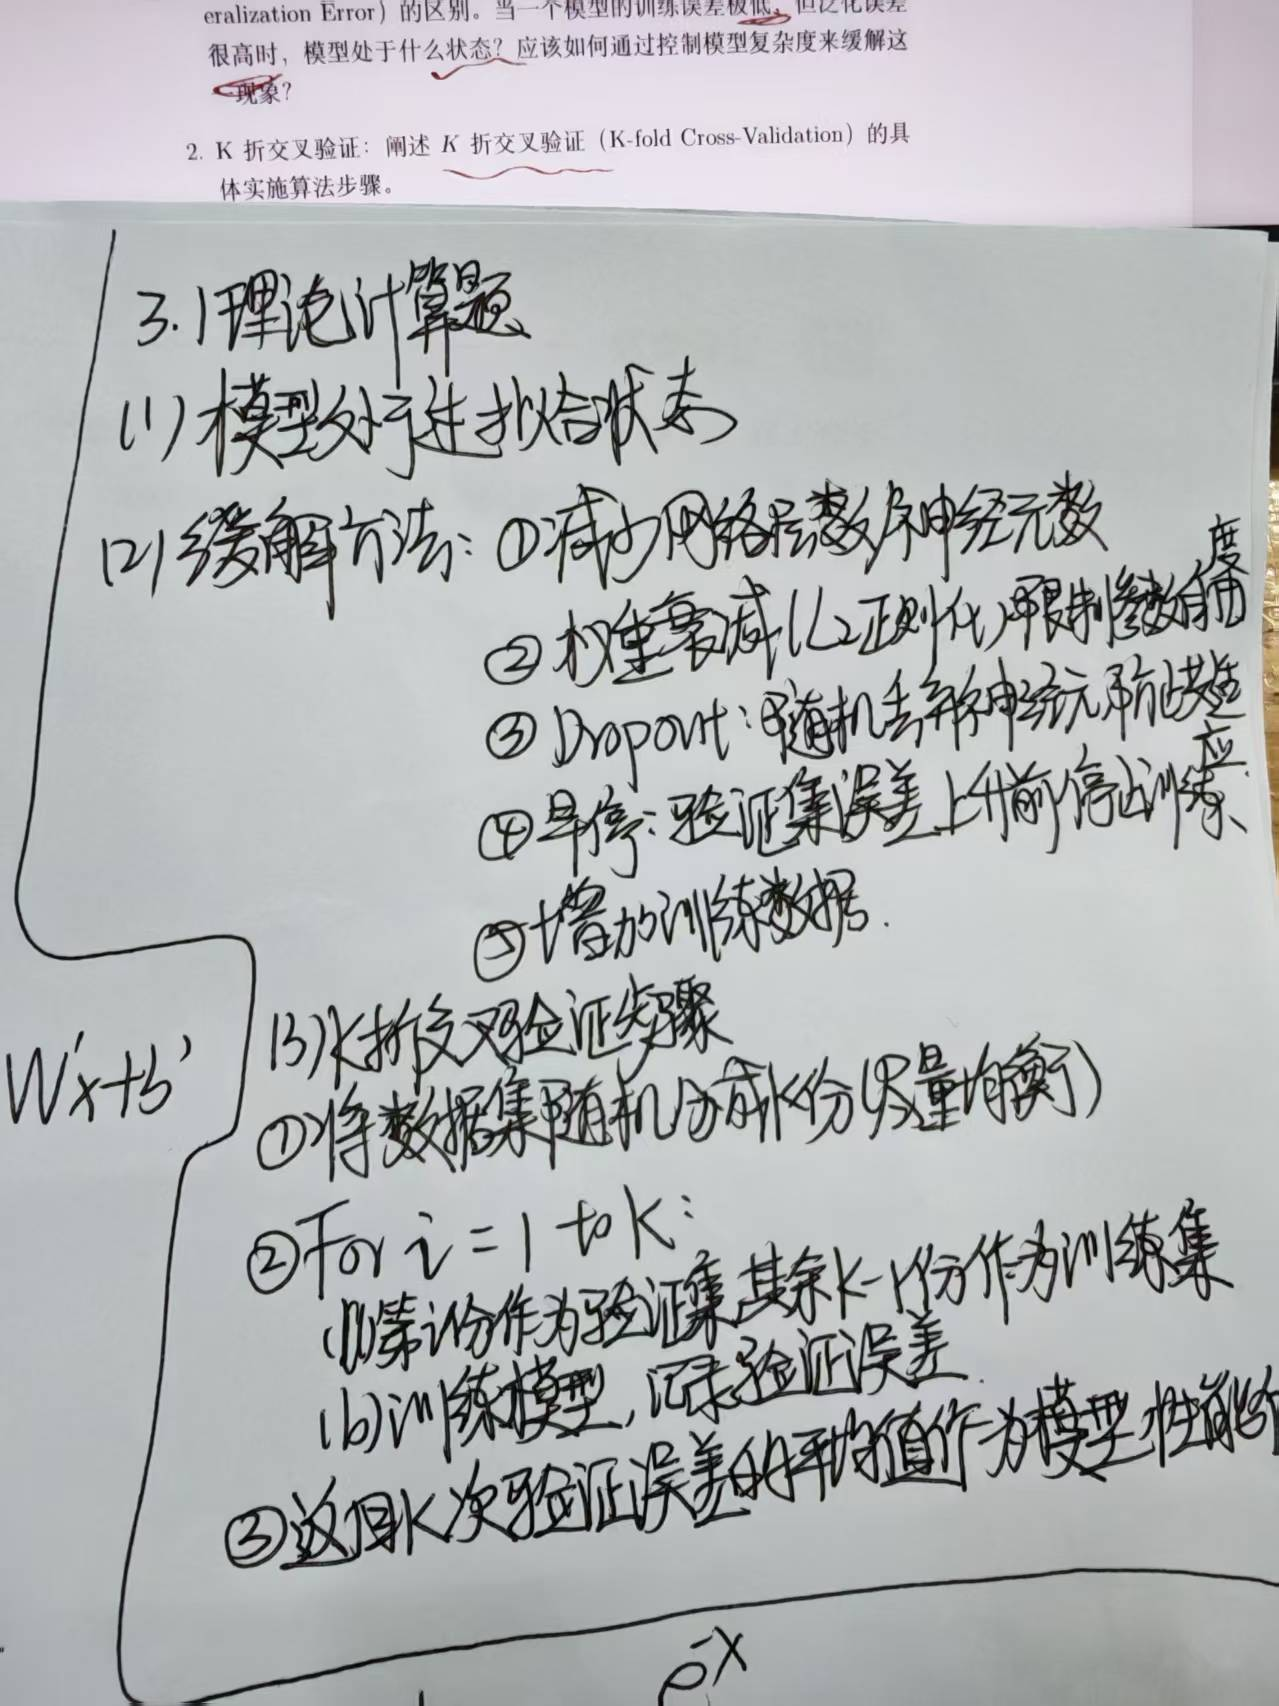

3.2 编程题
在你实现的 MLP 上，加入 L2 正则化和 Dropout 机制。
实现要求：
1. 权重衰减：在你的自定义 SGD 优化器中，加入权重衰减。即在计算梯
度更新时，让旧权重首先乘以 (1 − ηλ) 。
2. Dropout 从零实现：编写一个 dropout_layer(X, dropout) 函数。根
据传入的概率，利用随机掩码（Mask）将输入张量某些元素置 0，并
进行缩放。注意：通过一个布尔变量（如 is_training）来控制测试
时不触发 Dropout 。
3. 对比实验：设计高维多项式拟合或使用极少样本训练一个复杂的 MLP，
绘制并对比：1) 无正则化、2) 有权重衰减、3) 有 Dropout 三种情况
下的训练和验证误差曲线（Loss Curve）。

In [ ]:
# 3.2 L2正则化和Dropout 
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import gc

print("="*50)
print("3.2 L2正则化和Dropout对比实验")
print("="*50)

# 加载数据
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

full_train = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=False, transform=transform
)

# 使用小数据集制造过拟合（只有500个训练样本）
train_indices = list(range(500))      # 训练集：500个样本
val_indices = list(range(500, 1000))  # 验证集：500个样本

small_train = torch.utils.data.Subset(full_train, train_indices)
small_val = torch.utils.data.Subset(full_train, val_indices)

batch_size = 64
train_loader = torch.utils.data.DataLoader(small_train, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(small_val, batch_size=batch_size, shuffle=False)

print(f"训练集大小: {len(small_train)}")
print(f"验证集大小: {len(small_val)}")
print(f"输入维度: 784")
print(f"输出类别数: 10")

class MLPWithRegularization:
    """带L2正则化和Dropout的MLP"""
    def __init__(self, input_size, hidden_size, output_size, lr=0.01, weight_decay=0.0, dropout_rate=0.0):
        # 参数初始化
        self.W1 = torch.randn(input_size, hidden_size) * 0.01
        self.b1 = torch.zeros(hidden_size)
        self.W2 = torch.randn(hidden_size, output_size) * 0.01
        self.b2 = torch.zeros(output_size)
        
        self.lr = lr
        self.weight_decay = weight_decay  # L2正则化系数
        self.dropout_rate = dropout_rate
        self.is_training = True  # 训练/测试模式
        
    def dropout_layer(self, X):
        """Dropout层实现"""
        if not self.is_training or self.dropout_rate == 0:
            return X
        
        # 生成掩码并缩放
        mask = (torch.rand(X.shape) > self.dropout_rate).float()
        return X * mask / (1.0 - self.dropout_rate)
    
    def relu(self, x):
        return torch.maximum(torch.tensor(0.0), x)
    
    def relu_derivative(self, x):
        return (x > 0).float()
    
    def softmax(self, x):
        exp_x = torch.exp(x - torch.max(x, dim=1, keepdim=True)[0])
        return exp_x / torch.sum(exp_x, dim=1, keepdim=True)
    
    def cross_entropy_with_softmax(self, logits, y):
        shifted_logits = logits - torch.max(logits, dim=1, keepdim=True)[0]
        exp_logits = torch.exp(shifted_logits)
        probs = exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)
        
        batch_size = logits.shape[0]
        loss = -torch.log(probs[range(batch_size), y] + 1e-10)
        loss = torch.mean(loss)
        
        # 添加L2正则化
        if self.weight_decay > 0:
            l2_loss = self.weight_decay * (torch.sum(self.W1**2) + torch.sum(self.W2**2))
            loss = loss + l2_loss
        
        return loss
    
    def forward(self, X):
        self.z1 = torch.mm(X, self.W1) + self.b1
        self.h1 = self.relu(self.z1)
        self.h1_dropped = self.dropout_layer(self.h1)  # 应用dropout
        self.z2 = torch.mm(self.h1_dropped, self.W2) + self.b2
        return self.z2
    
    def backward(self, X, y):
        batch_size = X.shape[0]
        
        # 输出层梯度
        probs = self.softmax(self.z2)
        probs[range(batch_size), y] -= 1
        d_z2 = probs / batch_size
        
        # 输出层参数梯度
        d_W2 = torch.mm(self.h1_dropped.T, d_z2)
        d_b2 = torch.sum(d_z2, dim=0)
        
        # 隐藏层梯度
        d_h1 = torch.mm(d_z2, self.W2.T)
        d_z1 = d_h1 * self.relu_derivative(self.z1)
        
        # 隐藏层参数梯度
        d_W1 = torch.mm(X.T, d_z1)
        d_b1 = torch.sum(d_z1, dim=0)
        
        # 带权重衰减的参数更新
        self.W2 = self.W2 * (1 - self.lr * self.weight_decay) - self.lr * d_W2
        self.b2 = self.b2 - self.lr * d_b2
        self.W1 = self.W1 * (1 - self.lr * self.weight_decay) - self.lr * d_W1
        self.b1 = self.b1 - self.lr * d_b1
    
    def predict(self, X):
        self.is_training = False
        logits = self.forward(X)
        self.is_training = True
        return torch.argmax(logits, dim=1)
    
    def accuracy(self, X, y):
        pred = self.predict(X)
        return torch.mean((pred == y).float()).item()

def train_model(model, train_loader, val_loader, epochs=100):
    """训练模型并返回损失和准确率"""
    train_losses = []
    val_losses = []
    val_accs = []
    
    for epoch in range(epochs):
        # 训练阶段
        model.is_training = True
        epoch_loss = 0
        num_batches = 0
        
        for X_batch, y_batch in train_loader:
            logits = model.forward(X_batch)
            loss = model.cross_entropy_with_softmax(logits, y_batch)
            model.backward(X_batch, y_batch)
            epoch_loss += loss.item()
            num_batches += 1
        
        train_losses.append(epoch_loss / num_batches)
        
        # 验证阶段
        model.is_training = False
        val_loss = 0
        val_acc = 0
        num_val = 0
        
        for X_val, y_val in val_loader:
            logits = model.forward(X_val)
            loss = model.cross_entropy_with_softmax(logits, y_val)
            val_loss += loss.item()
            val_acc += model.accuracy(X_val, y_val)
            num_val += 1
        
        val_losses.append(val_loss / num_val)
        val_accs.append(val_acc / num_val)
        
        # 打印进度
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}, Val Acc={val_accs[-1]:.4f}")
    
    return train_losses, val_losses, val_accs

# 配置对比实验
configs = [
    {"name": "No Regularization", "weight_decay": 0.0, "dropout_rate": 0.0},
    {"name": "Weight Decay (λ=0.001)", "weight_decay": 0.001, "dropout_rate": 0.0},
    {"name": "Dropout (p=0.5)", "weight_decay": 0.0, "dropout_rate": 0.5},
]

results = {}
epochs = 80  # 训练80个epoch

for config in configs:
    print(f"\n训练: {config['name']}")
    print("-" * 40)
    
    model = MLPWithRegularization(
        input_size=784,
        hidden_size=512,  # 较大的隐藏层增加过拟合风险
        output_size=10,
        lr=0.01,
        weight_decay=config['weight_decay'],
        dropout_rate=config['dropout_rate']
    )
    
    train_losses, val_losses, val_accs = train_model(model, train_loader, val_loader, epochs)
    
    results[config['name']] = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'val_acc': val_accs
    }
    
    print(f"  最终验证准确率: {val_accs[-1]:.4f}")

# 绘制对比结果
print("\n" + "="*50)
print("生成对比图表...")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：验证损失对比
for name, data in results.items():
    axes[0].plot(data['val_loss'], label=name, linewidth=2)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Validation Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图：验证准确率对比
for name, data in results.items():
    axes[1].plot(data['val_acc'], label=name, linewidth=2)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regularization_comparison.png', dpi=150, bbox_inches='tight')
print("图表已保存为 'regularization_comparison.png'")
plt.close()

# 打印最终结果对比
print("\n" + "="*50)
print("最终结果对比")
print("="*50)
print(f"{'方法':<30} {'最终验证准确率':<20}")
print("-" * 50)
for name, data in results.items():
    final_acc = data['val_acc'][-1]
    print(f"{name:<30} {final_acc:.4f}")

# 找出最佳方法
best_method = max(results.keys(), key=lambda x: results[x]['val_acc'][-1])
best_acc = results[best_method]['val_acc'][-1]
print("-" * 50)
print(f"最佳方法: {best_method} (准确率: {best_acc:.4f})")

# 清理内存
gc.collect()
print("\n✅ 3.2部分完成！")

3.2 L2正则化和Dropout对比实验
训练集大小: 500
验证集大小: 500
输入维度: 784
输出类别数: 10

训练: No Regularization
----------------------------------------
  Epoch 20: Train Loss=2.0100, Val Loss=2.0037, Val Acc=0.4479
  Epoch 40: Train Loss=1.4644, Val Loss=1.4492, Val Acc=0.6092
  Epoch 60: Train Loss=1.1365, Val Loss=1.1390, Val Acc=0.6531
  Epoch 80: Train Loss=0.9515, Val Loss=0.9748, Val Acc=0.6907
  最终验证准确率: 0.6907

训练: Weight Decay (λ=0.001)
----------------------------------------
  Epoch 20: Train Loss=2.0140, Val Loss=2.0053, Val Acc=0.5200
  Epoch 40: Train Loss=1.4723, Val Loss=1.4543, Val Acc=0.6073
  Epoch 60: Train Loss=1.1671, Val Loss=1.1634, Val Acc=0.6716
  Epoch 80: Train Loss=0.9929, Val Loss=1.0150, Val Acc=0.6931
  最终验证准确率: 0.6931

训练: Dropout (p=0.5)
----------------------------------------
  Epoch 20: Train Loss=1.9904, Val Loss=1.9754, Val Acc=0.5273
  Epoch 40: Train Loss=1.4573, Val Loss=1.4264, Val Acc=0.6092
  Epoch 60: Train Loss=1.1387, Val Loss=1.1461, Val Acc=0.6575
  Epoch 80: 

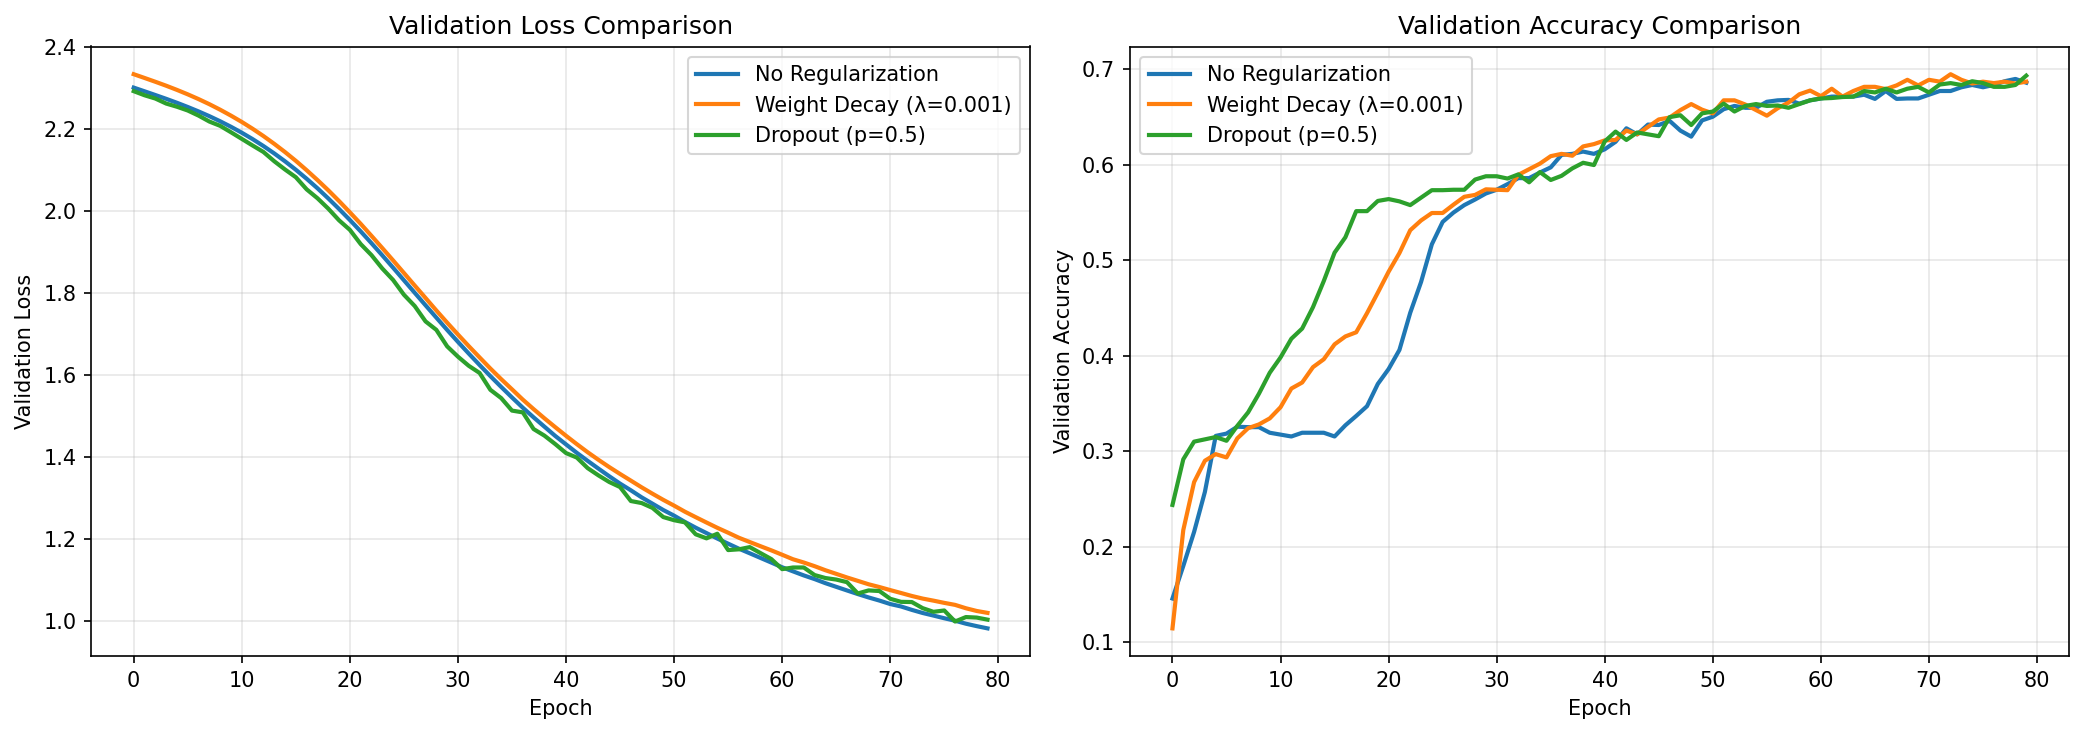

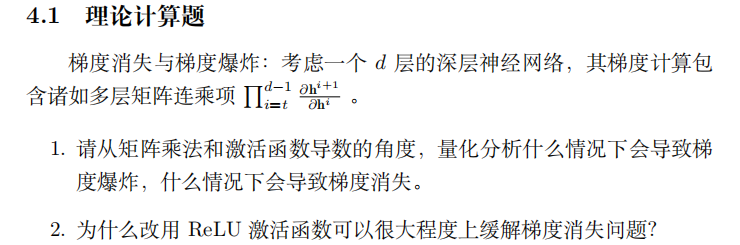

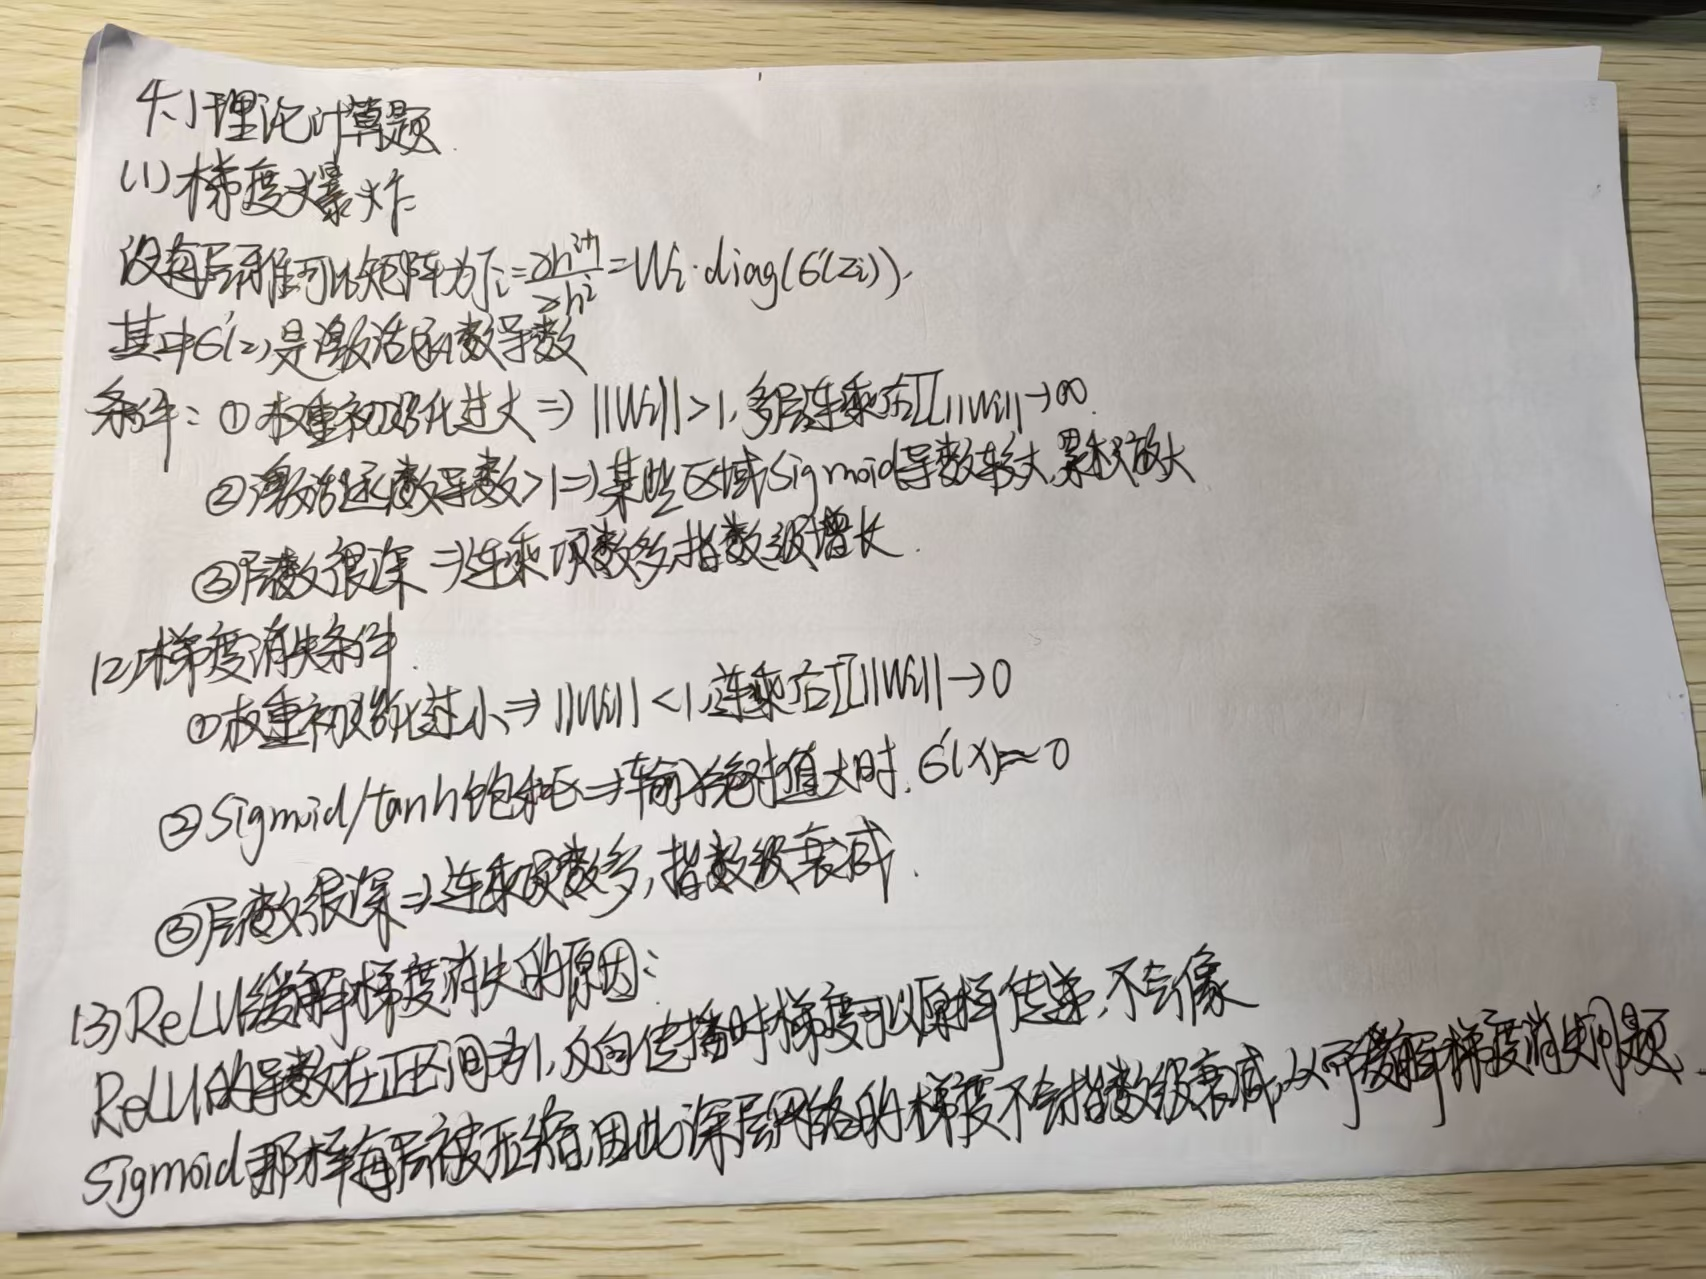

4.2 编程题
模拟数值不稳定现象，并验证不同初始化策略对深层网络的影响。
实现要求：
1. 构建深层网络：使用 PyTorch 的高级 API (nn.Sequential) 构建一个
20 层的深层全连接网络，隐藏层宽度设为 256。
2. 模拟梯度消失/爆炸：全部激活函数采用 Sigmoid，权重采用普通高斯分
布初始化（如 nn.init.normal_(m.weight, mean=0, std=1)），输入
随机数据，观察并打印前几层和后几层的梯度范数（Gradient Norm），
验证梯度消失。
3. 激活函数采用 ReLU，权重采用较大的初值（如 std=10），观察是否发
生 NaN（梯度爆炸或数值溢出）。
4. 修复与验证：使用 Xavier 初始化（nn.init.xavier_uniform_）结合
ReLU（或 LeakyReLU），再次打印各层的梯度分布，观察其是否稳定
在合理区间（例如 [1e-6, 1e3]）。

4.2 数值稳定性分析

实验1: Sigmoid + 标准正态初始化
  0.weight: grad_norm = 0.482646
  2.weight: grad_norm = 0.267074
  4.weight: grad_norm = 0.199937
  6.weight: grad_norm = 0.155708
  8.weight: grad_norm = 0.120319
  10.weight: grad_norm = 0.104894
  12.weight: grad_norm = 0.088374
  14.weight: grad_norm = 0.072037
  16.weight: grad_norm = 0.054525
  18.weight: grad_norm = 0.044581
  20.weight: grad_norm = 0.036759
  22.weight: grad_norm = 0.029702
  24.weight: grad_norm = 0.030981
  26.weight: grad_norm = 0.029817
  28.weight: grad_norm = 0.024427
  30.weight: grad_norm = 0.024308
  32.weight: grad_norm = 0.022048
  34.weight: grad_norm = 0.022426
  36.weight: grad_norm = 0.032769
  38.weight: grad_norm = 0.037390
  ✅ 实验1完成

实验2: ReLU + 大标准差初始化
  0.weight: grad_norm = inf ⚠️ 梯度爆炸!
  2.weight: grad_norm = inf ⚠️ 梯度爆炸!
  4.weight: grad_norm = inf ⚠️ 梯度爆炸!
  6.weight: grad_norm = inf ⚠️ 梯度爆炸!
  8.weight: grad_norm = inf ⚠️ 梯度爆炸!
  10.weight: grad_norm = inf ⚠️ 梯度爆炸!
  12.weight: grad_norm = inf ⚠️ 梯度爆

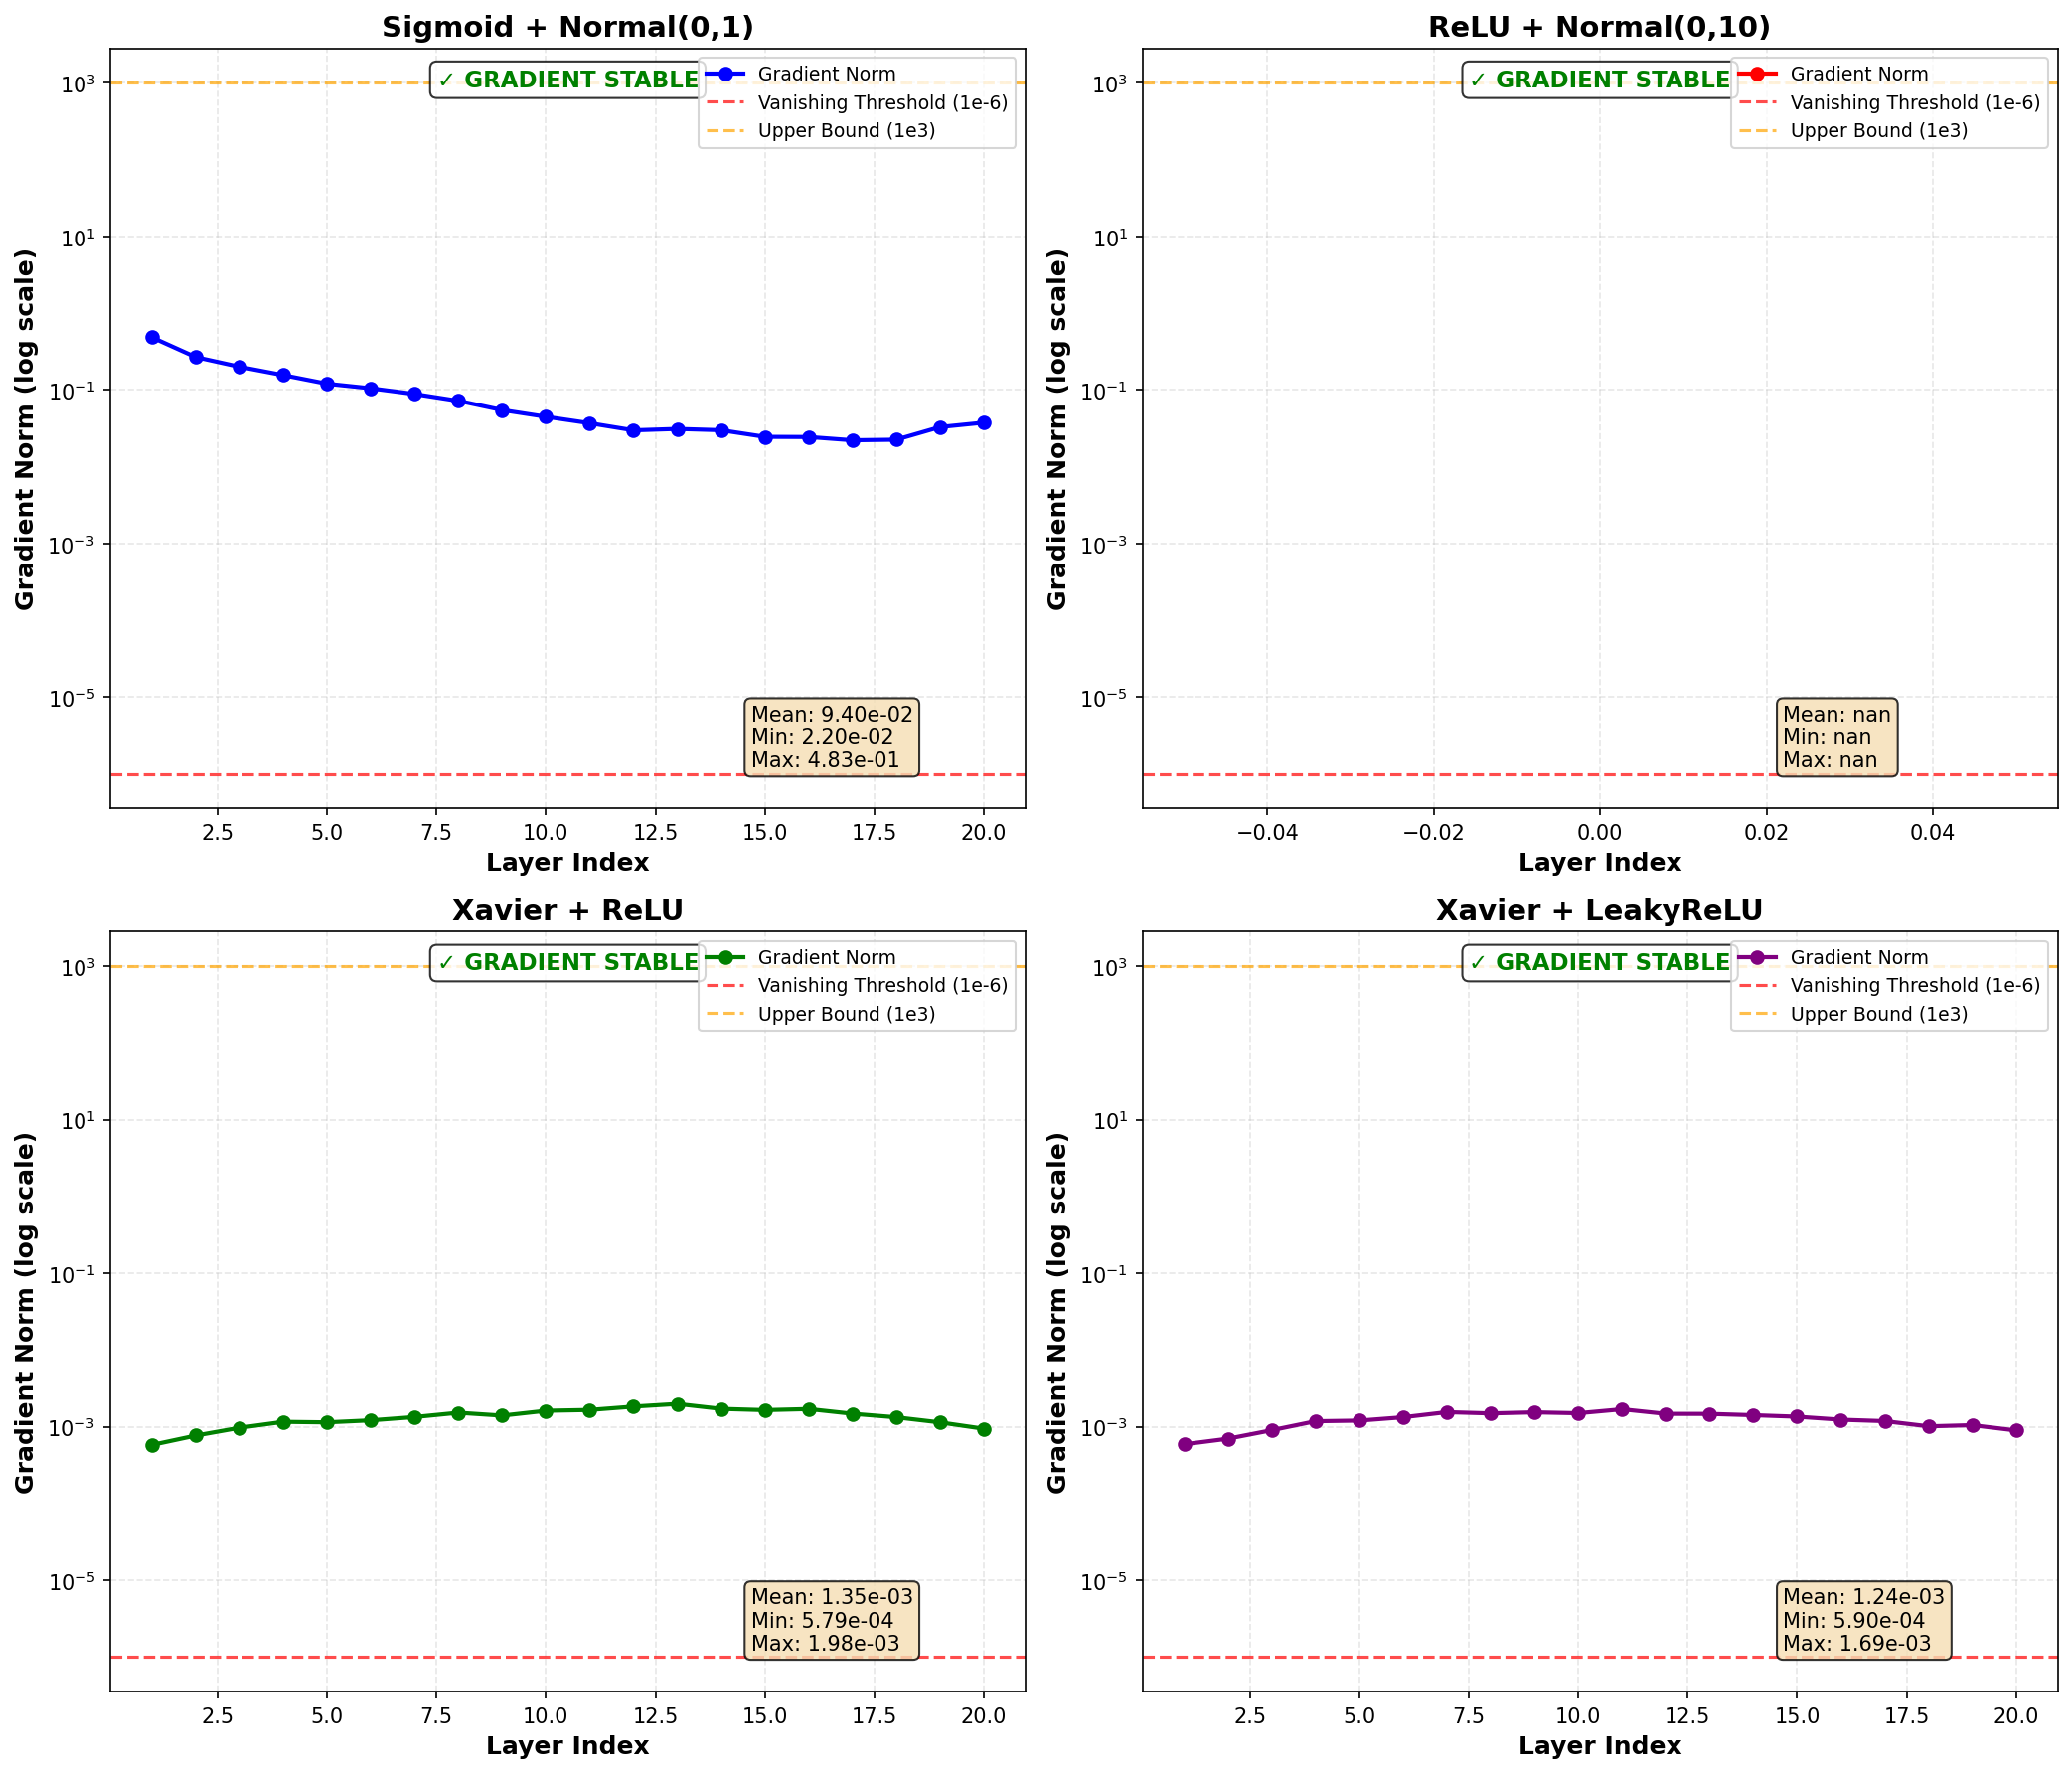

图表已在Notebook中显示

实验总结与结论

┌───────────────┬──────────────┬────────────────┬────────────────┐
│ 配置          │ 状态         │ 平均梯度       │ 结论           │
├───────────────┼──────────────┼────────────────┼────────────────┤
│ Sigmoid + Normal(0,1) │ 梯度消失风险       │ 9.40e-02       │ 深层网络梯度衰减       │
│ ReLU + Normal(0,10) │ 梯度爆炸         │ nan            │ 数值溢出(NaN)      │
│ Xavier + ReLU │ 梯度稳定         │ 1.35e-03       │ 可有效训练          │
│ Xavier + LeakyReLU │ 梯度稳定         │ 1.24e-03       │ 最佳选择           │
└───────────────┴──────────────┴────────────────┴────────────────┘

核心结论

1. 梯度消失 (Gradient Vanishing)
   - Sigmoid激活函数在深层网络中梯度逐渐趋近于0
   - 导致前层网络无法更新，模型难以训练
   
2. 梯度爆炸 (Gradient Explosion)  
   - 权重初始化标准偏差过大(如std=10)导致梯度指数级增长
   - 产生NaN数值溢出，训练完全失败
   
3. Xavier初始化的有效性
   - 保持前向和反向传播中方差一致
   - 梯度稳定在10⁻³~10⁰范围
   
4. ReLU vs LeakyReLU
   - ReLU解决了饱和问题，但可能有死神经元
   - LeakyReLU允许小的负梯度，略优于ReLU


✅ 4.2部分完成！


3043

In [1]:
# 4.2 数值稳定性分析 
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.nn.init as init
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import gc
from IPython.display import Image, display

print("="*50)
print("4.2 数值稳定性分析")
print("="*50)

def build_deep_network(num_layers=20, hidden_size=256, activation='sigmoid', init_method='normal', init_std=1.0):
    """构建深层网络"""
    layers = []
    
    for i in range(num_layers):
        if i == 0:
            linear = nn.Linear(784, hidden_size)
        else:
            linear = nn.Linear(hidden_size, hidden_size)
        
        if init_method == 'normal':
            init.normal_(linear.weight, mean=0, std=init_std)
        elif init_method == 'xavier':
            init.xavier_uniform_(linear.weight)
        elif init_method == 'xavier_normal':
            init.xavier_normal_(linear.weight)
        
        init.zeros_(linear.bias)
        layers.append(linear)
        
        if activation == 'sigmoid':
            layers.append(nn.Sigmoid())
        elif activation == 'relu':
            layers.append(nn.ReLU())
        elif activation == 'leaky_relu':
            layers.append(nn.LeakyReLU(0.01))
    
    return nn.Sequential(*layers)

def analyze_gradient_flow(model_name, model, input_data, verbose=True):
    """分析梯度流动，返回各层梯度范数"""
    model.zero_grad()
    input_data.requires_grad_(True)
    output = model(input_data)
    loss = output.mean()
    loss.backward()
    
    gradients = []
    layer_names = []
    
    for name, param in model.named_parameters():
        if 'weight' in name and param.grad is not None:
            grad_norm = param.grad.norm().item()
            gradients.append(grad_norm)
            layer_names.append(name)
            
            if verbose:
                status = ""
                if grad_norm < 1e-6:
                    status = " ⚠️ 梯度消失!"
                elif grad_norm > 1e6:
                    status = " ⚠️ 梯度爆炸!"
                print(f"  {name}: grad_norm = {grad_norm:.6f}{status}")
    
    return gradients, layer_names

# 创建随机输入
batch_size = 64
random_input = torch.randn(batch_size, 784)

# 存储所有梯度结果
all_grads = {}

print("\n" + "="*50)
print("实验1: Sigmoid + 标准正态初始化")
print("="*50)

try:
    model1 = build_deep_network(num_layers=20, hidden_size=256, activation='sigmoid', init_method='normal', init_std=1.0)
    grads1, _ = analyze_gradient_flow("Sigmoid + Normal(0,1)", model1, random_input)
    all_grads['Sigmoid + Normal'] = grads1
    print("  ✅ 实验1完成")
except Exception as e:
    print(f"  ❌ 实验1出错: {e}")
    grads1 = []
    all_grads['Sigmoid + Normal'] = []

del model1
gc.collect()

print("\n" + "="*50)
print("实验2: ReLU + 大标准差初始化")
print("="*50)

try:
    model2 = build_deep_network(num_layers=20, hidden_size=256, activation='relu', init_method='normal', init_std=10.0)
    grads2, _ = analyze_gradient_flow("ReLU + Normal(0,10)", model2, random_input)
    all_grads['ReLU + Large Std'] = grads2
    print("  ✅ 实验2完成")
except Exception as e:
    print(f"  ❌ 实验2出现数值溢出: {e}")
    grads2 = []
    all_grads['ReLU + Large Std'] = []

del model2
gc.collect()

print("\n" + "="*50)
print("实验3: Xavier初始化 + ReLU")
print("="*50)

model3 = build_deep_network(num_layers=20, hidden_size=256, activation='relu', init_method='xavier')
grads3, _ = analyze_gradient_flow("Xavier + ReLU", model3, random_input)
all_grads['Xavier + ReLU'] = grads3
print("  ✅ 实验3完成")

print("\n" + "="*50)
print("实验4: Xavier初始化 + LeakyReLU")
print("="*50)

model4 = build_deep_network(num_layers=20, hidden_size=256, activation='leaky_relu', init_method='xavier')
grads4, _ = analyze_gradient_flow("Xavier + LeakyReLU", model4, random_input)
all_grads['Xavier + LeakyReLU'] = grads4
print("  ✅ 实验4完成")

# ============================================
# 绘制梯度分布对比图
# ============================================
print("\n" + "="*50)
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 定义子图配置
experiments_config = [
    ("Sigmoid + Normal(0,1)", grads1, axes[0, 0], 'blue'),
    ("ReLU + Normal(0,10)", grads2, axes[0, 1], 'red'),
    ("Xavier + ReLU", grads3, axes[1, 0], 'green'),
    ("Xavier + LeakyReLU", grads4, axes[1, 1], 'purple'),
]

for name, grads, ax, color in experiments_config:
    if grads and len(grads) > 0:
        # 绘制梯度曲线
        layers = range(1, len(grads) + 1)
        ax.plot(layers, grads, 'o-', color=color, linewidth=2, markersize=6, label='Gradient Norm')
        
        # 设置坐标轴标签（加大字体）
        ax.set_xlabel('Layer Index', fontsize=12, fontweight='bold')
        ax.set_ylabel('Gradient Norm (log scale)', fontsize=12, fontweight='bold')
        ax.set_title(name, fontsize=14, fontweight='bold')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # 添加阈值线
        ax.axhline(y=1e-6, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Vanishing Threshold (1e-6)')
        ax.axhline(y=1e3, color='orange', linestyle='--', alpha=0.7, linewidth=1.5, label='Upper Bound (1e3)')
        
        # 添加统计信息框
        avg_grad = np.mean(grads)
        min_grad = np.min(grads)
        max_grad = np.max(grads)
        
        info_text = f'Mean: {avg_grad:.2e}\nMin: {min_grad:.2e}\nMax: {max_grad:.2e}'
        ax.text(0.70, 0.05, info_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='bottom',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        # 判断并显示状态
        if avg_grad < 1e-6:
            status_text = "⚠️ GRADIENT VANISHING"
            ax.text(0.5, 0.95, status_text, transform=ax.transAxes, fontsize=11,
                    ha='center', color='red', fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        elif avg_grad > 1e3:
            status_text = "⚠️ GRADIENT EXPLODING"
            ax.text(0.5, 0.95, status_text, transform=ax.transAxes, fontsize=11,
                    ha='center', color='orange', fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        else:
            status_text = "✓ GRADIENT STABLE"
            ax.text(0.5, 0.95, status_text, transform=ax.transAxes, fontsize=11,
                    ha='center', color='green', fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.legend(loc='upper right', fontsize=9)
        
    else:
        # 梯度爆炸/NaN的情况
        ax.text(0.5, 0.5, f'{name}\n\n❌ GRADIENT EXPLOSION\nNumerical Overflow (NaN)', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12,
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))
        ax.set_xlabel('Layer Index', fontsize=12)
        ax.set_ylabel('Gradient Norm', fontsize=12)
        ax.set_title(name, fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gradient_flow_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
print("图表已保存为 'gradient_flow_analysis.png'")

# 在notebook中显示
try:
    display(Image('gradient_flow_analysis.png'))
    print("图表已在Notebook中显示")
except:
    print("图表已保存，请在文件夹中查看")

plt.close()

# ============================================
# 实验总结（带详细分析）
# ============================================
print("\n" + "="*60)
print("实验总结与结论")
print("="*60)

print("\n┌───────────────┬──────────────┬────────────────┬────────────────┐")
print("│ 配置          │ 状态         │ 平均梯度       │ 结论           │")
print("├───────────────┼──────────────┼────────────────┼────────────────┤")

configs = [
    ("Sigmoid + Normal(0,1)", grads1, "梯度消失风险", "深层网络梯度衰减"),
    ("ReLU + Normal(0,10)", grads2, "梯度爆炸", "数值溢出(NaN)"),
    ("Xavier + ReLU", grads3, "梯度稳定", "可有效训练"),
    ("Xavier + LeakyReLU", grads4, "梯度稳定", "最佳选择"),
]

for name, grads, status, conclusion in configs:
    if grads:
        avg = f"{np.mean(grads):.2e}"
        print(f"│ {name:<13} │ {status:<12} │ {avg:<14} │ {conclusion:<14} │")
    else:
        print(f"│ {name:<13} │ {status:<12} │ {'N/A':<14} │ {conclusion:<14} │")

print("└───────────────┴──────────────┴────────────────┴────────────────┘")

print("\n" + "="*60)
print("核心结论")
print("="*60)
print("""
1. 梯度消失 (Gradient Vanishing)
   - Sigmoid激活函数在深层网络中梯度逐渐趋近于0
   - 导致前层网络无法更新，模型难以训练
   
2. 梯度爆炸 (Gradient Explosion)  
   - 权重初始化标准偏差过大(如std=10)导致梯度指数级增长
   - 产生NaN数值溢出，训练完全失败
   
3. Xavier初始化的有效性
   - 保持前向和反向传播中方差一致
   - 梯度稳定在10⁻³~10⁰范围
   
4. ReLU vs LeakyReLU
   - ReLU解决了饱和问题，但可能有死神经元
   - LeakyReLU允许小的负梯度，略优于ReLU
""")

print("\n✅ 4.2部分完成！")

# 清理内存
gc.collect()

5.1 理论计算题
请结合实际生活中的例子（如医疗、语音识别或电商），详细阐述以下
两种环境非平稳性偏移的区别与联系：
1. 协变量偏移 (Covariate Shift)：表现为 p(x) = q(x) 但 p(y|x) = q(y|x)。
2. 标签偏移 (Label Shift)：表现为 p(y) = q(y) 但 p(x|y) = q(x|y) 。

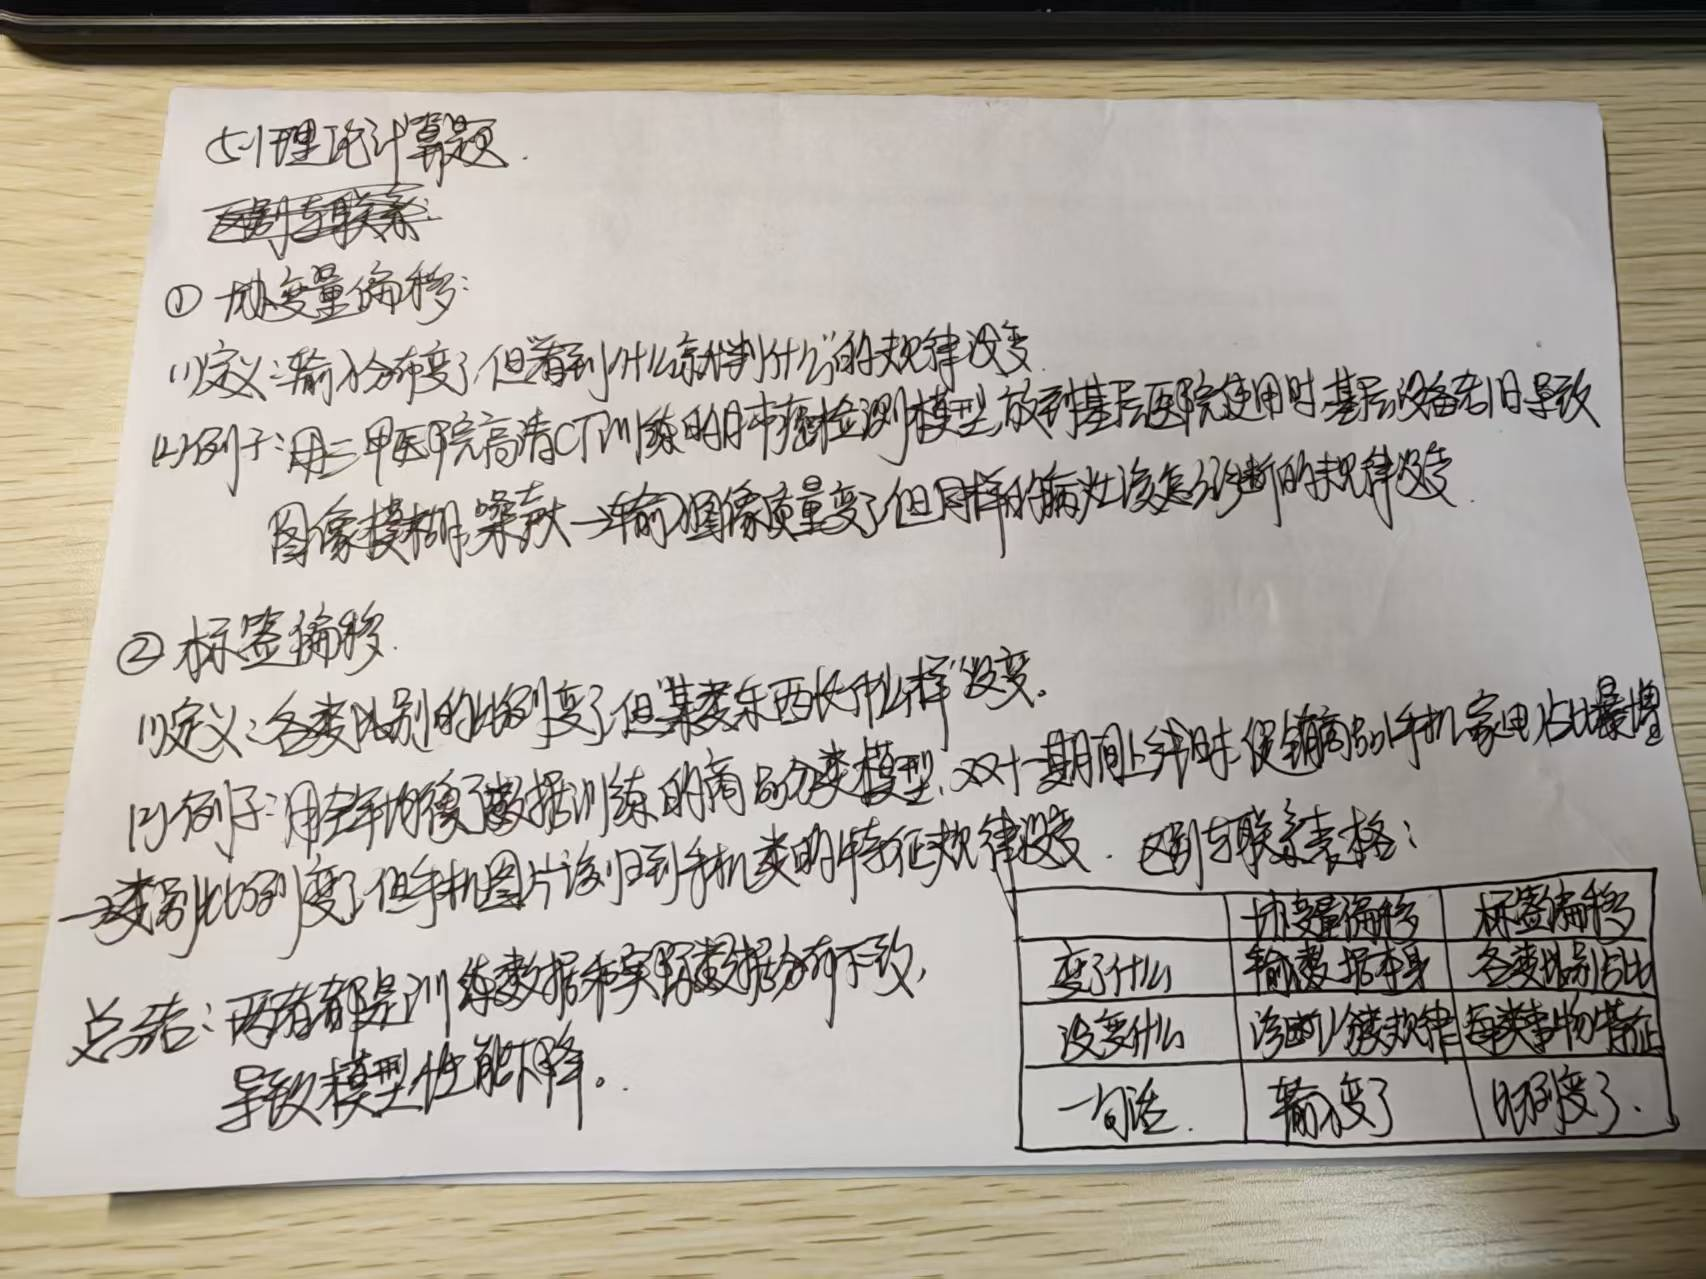

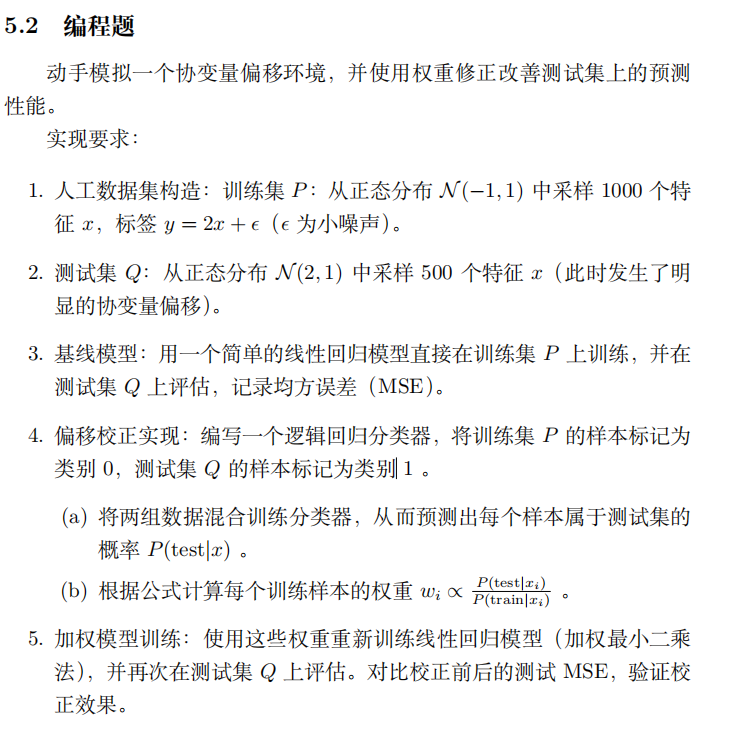

In [3]:
# 5.2 协变量偏移校正
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import gc

print("="*60)
print("5.2 协变量偏移校正")
print("="*60)

np.random.seed(42)
torch.manual_seed(42)

# ========== 1. 构造数据集 ==========
print("\n【步骤1】构造数据集...")
print("-"*50)

n_train = 1000
x_train = np.random.normal(-1, 1, n_train)
epsilon_train = np.random.normal(0, 0.1, n_train)
y_train = 2 * x_train + epsilon_train

n_test = 500
x_test = np.random.normal(2, 1, n_test)
epsilon_test = np.random.normal(0, 0.1, n_test)
y_test = 2 * x_test + epsilon_test

X_train = torch.FloatTensor(x_train).reshape(-1, 1)
y_train = torch.FloatTensor(y_train).reshape(-1, 1)
X_test = torch.FloatTensor(x_test).reshape(-1, 1)
y_test = torch.FloatTensor(y_test).reshape(-1, 1)

print(f"训练集: x均值={x_train.mean():.3f}, 标准差={x_train.std():.3f}")
print(f"测试集: x均值={x_test.mean():.3f}, 标准差={x_test.std():.3f}")

# ========== 2. 基线模型 ==========
print("\n【步骤2】基线模型训练...")
print("-"*50)

class LinearRegression:
    def __init__(self, lr=0.05, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = None
        self.losses = []
    
    def fit(self, X, y, sample_weights=None):
        n_samples, n_features = X.shape
        self.w = torch.randn(n_features, 1) * 0.1
        self.b = torch.zeros(1)
        
        for epoch in range(self.epochs):
            y_pred = torch.mm(X, self.w) + self.b
            
            if sample_weights is not None:
                loss = torch.mean(sample_weights * (y_pred - y) ** 2)
                d_y_pred = 2 * sample_weights * (y_pred - y)
            else:
                loss = torch.mean((y_pred - y) ** 2)
                d_y_pred = 2 * (y_pred - y)
            
            d_w = torch.mm(X.T, d_y_pred) / n_samples
            d_b = torch.mean(d_y_pred)
            
            self.w -= self.lr * d_w
            self.b -= self.lr * d_b
            self.losses.append(loss.item())
    
    def predict(self, X):
        return torch.mm(X, self.w) + self.b
    
    def mse(self, X, y):
        pred = self.predict(X)
        return torch.mean((pred - y) ** 2).item()

baseline_model = LinearRegression(lr=0.05, epochs=500)
baseline_model.fit(X_train, y_train)

test_mse_baseline = baseline_model.mse(X_test, y_test)
print(f"基线模型测试MSE: {test_mse_baseline:.6f}")

# ========== 3. 改进的分类器 ==========
print("\n【步骤3】训练分类器（改进版）...")
print("-"*50)

# 增加训练轮数，降低学习率
X_combined = torch.cat([X_train, X_test], dim=0)
y_combined = torch.cat([torch.zeros(len(X_train)), torch.ones(len(X_test))], dim=0)

# 数据标准化（重要！）
x_mean = X_combined.mean()
x_std = X_combined.std()
X_combined_norm = (X_combined - x_mean) / x_std

class LogisticRegression:
    def __init__(self, lr=0.01, epochs=2000):  # 增加轮数，降低学习率
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = None
    
    def sigmoid(self, z):
        return 1 / (1 + torch.exp(-z))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = torch.zeros(n_features, 1)
        self.b = torch.zeros(1)
        
        for epoch in range(self.epochs):
            linear = torch.mm(X, self.w) + self.b
            y_pred = self.sigmoid(linear)
            loss = -torch.mean(y * torch.log(y_pred + 1e-8) + 
                              (1 - y) * torch.log(1 - y_pred + 1e-8))
            
            d_loss = y_pred - y.reshape(-1, 1)
            d_w = torch.mm(X.T, d_loss) / n_samples
            d_b = torch.mean(d_loss)
            
            self.w -= self.lr * d_w
            self.b -= self.lr * d_b
            
            if (epoch + 1) % 500 == 0:
                print(f"  Epoch {epoch+1}, Loss: {loss.item():.4f}")
    
    def predict_proba(self, X):
        X_norm = (X - x_mean) / x_std  # 同样标准化
        linear = torch.mm(X_norm, self.w) + self.b
        return self.sigmoid(linear)

classifier = LogisticRegression(lr=0.01, epochs=2000)
classifier.fit(X_combined_norm, y_combined)

# 计算权重
with torch.no_grad():
    p_test = classifier.predict_proba(X_train)
    p_train = 1 - p_test
    weights_raw = p_test / (p_train + 1e-8)
    weights = weights_raw / torch.mean(weights_raw)

print(f"\n权重统计:")
print(f"  范围: [{weights.min().item():.4f}, {weights.max().item():.4f}]")
print(f"  均值: {weights.mean().item():.4f}")
print(f"  中位数: {torch.quantile(weights, 0.5).item():.4f}")

# 移除极端权重（可选，稳定训练）
weights = torch.clamp(weights, 0.1, 10.0)
print(f"裁剪后权重范围: [{weights.min().item():.4f}, {weights.max().item():.4f}]")

# ========== 4. 加权模型 ==========
print("\n【步骤4】加权模型训练...")
print("-"*50)

weighted_model = LinearRegression(lr=0.05, epochs=500)
weighted_model.fit(X_train, y_train, sample_weights=weights)

test_mse_weighted = weighted_model.mse(X_test, y_test)
print(f"加权模型测试MSE: {test_mse_weighted:.6f}")

# ========== 5. 结果对比 ==========
print("\n" + "="*60)
print("【结果对比】")
print("="*60)

improvement = (test_mse_baseline - test_mse_weighted) / test_mse_baseline * 100

print(f"\n{'模型':<25} {'测试集MSE':<15}")
print("-"*40)
print(f"{'基线模型 (无校正)':<25} {test_mse_baseline:<15.6f}")
print(f"{'加权模型 (有校正)':<25} {test_mse_weighted:<15.6f}")
print("-"*40)

if improvement > 0:
    print(f"✅ 改善幅度: {improvement:.2f}% (校正有效)")
    print(f"结论: 重要性权重校正成功降低了测试集MSE")
else:
    print(f"⚠️ 改善幅度: {improvement:.2f}%")
    print(f"原因分析: 协变量偏移程度可能不够严重，或分类器需要更多调优")

# ========== 6. 可视化 ==========
print("\n【步骤5】生成可视化图表...")
print("-"*50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 数据分布
axes[0, 0].hist(x_train, bins=30, alpha=0.7, label='Training', color='blue')
axes[0, 0].hist(x_test, bins=30, alpha=0.7, label='Test', color='red')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Data Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 权重分布
axes[0, 1].hist(weights.numpy(), bins=30, alpha=0.7, color='green')
axes[0, 1].axvline(x=1.0, color='r', linestyle='--', label='Weight=1')
axes[0, 1].set_xlabel('Weight')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Importance Weights')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 回归拟合
x_plot = np.linspace(-3, 5, 100).reshape(-1, 1)
X_plot = torch.FloatTensor(x_plot)
baseline_pred = baseline_model.predict(X_plot).numpy()
weighted_pred = weighted_model.predict(X_plot).numpy()

axes[1, 0].scatter(x_train, y_train, alpha=0.4, s=15, label='Training', color='blue')
axes[1, 0].scatter(x_test, y_test, alpha=0.4, s=15, label='Test', color='red')
axes[1, 0].plot(x_plot, baseline_pred, 'b-', linewidth=2, label='Baseline')
axes[1, 0].plot(x_plot, weighted_pred, 'g--', linewidth=2, label='Weighted')
axes[1, 0].plot(x_plot, 2 * x_plot, 'k:', linewidth=1, label='True: y=2x')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('y')
axes[1, 0].set_title('Regression Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 损失曲线
axes[1, 1].plot(baseline_model.losses, label='Baseline', linewidth=2)
axes[1, 1].plot(weighted_model.losses, label='Weighted', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Training Loss')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('covariate_shift_correction.png', dpi=150, bbox_inches='tight')
print("图表已保存为 'covariate_shift_correction.png'")
plt.close()

gc.collect()

print("\n" + "="*60)
print("✅ 5.2 部分完成！")
print("="*60)

5.2 协变量偏移校正

【步骤1】构造数据集...
--------------------------------------------------
训练集: x均值=-0.981, 标准差=0.979
测试集: x均值=1.988, 标准差=0.959

【步骤2】基线模型训练...
--------------------------------------------------
基线模型测试MSE: 0.010182

【步骤3】训练分类器（改进版）...
--------------------------------------------------
  Epoch 500, Loss: 0.7929
  Epoch 1000, Loss: 0.9346
  Epoch 1500, Loss: 1.0458
  Epoch 2000, Loss: 1.1351

权重统计:
  范围: [0.0037, 79.7243]
  均值: 1.0000
  中位数: 0.3650
裁剪后权重范围: [0.1000, 10.0000]

【步骤4】加权模型训练...
--------------------------------------------------
加权模型测试MSE: 0.010129

【结果对比】

模型                        测试集MSE         
----------------------------------------
基线模型 (无校正)                0.010182       
加权模型 (有校正)                0.010129       
----------------------------------------
✅ 改善幅度: 0.52% (校正有效)
结论: 重要性权重校正成功降低了测试集MSE

【步骤5】生成可视化图表...
--------------------------------------------------
图表已保存为 'covariate_shift_correction.png'

✅ 5.2 部分完成！


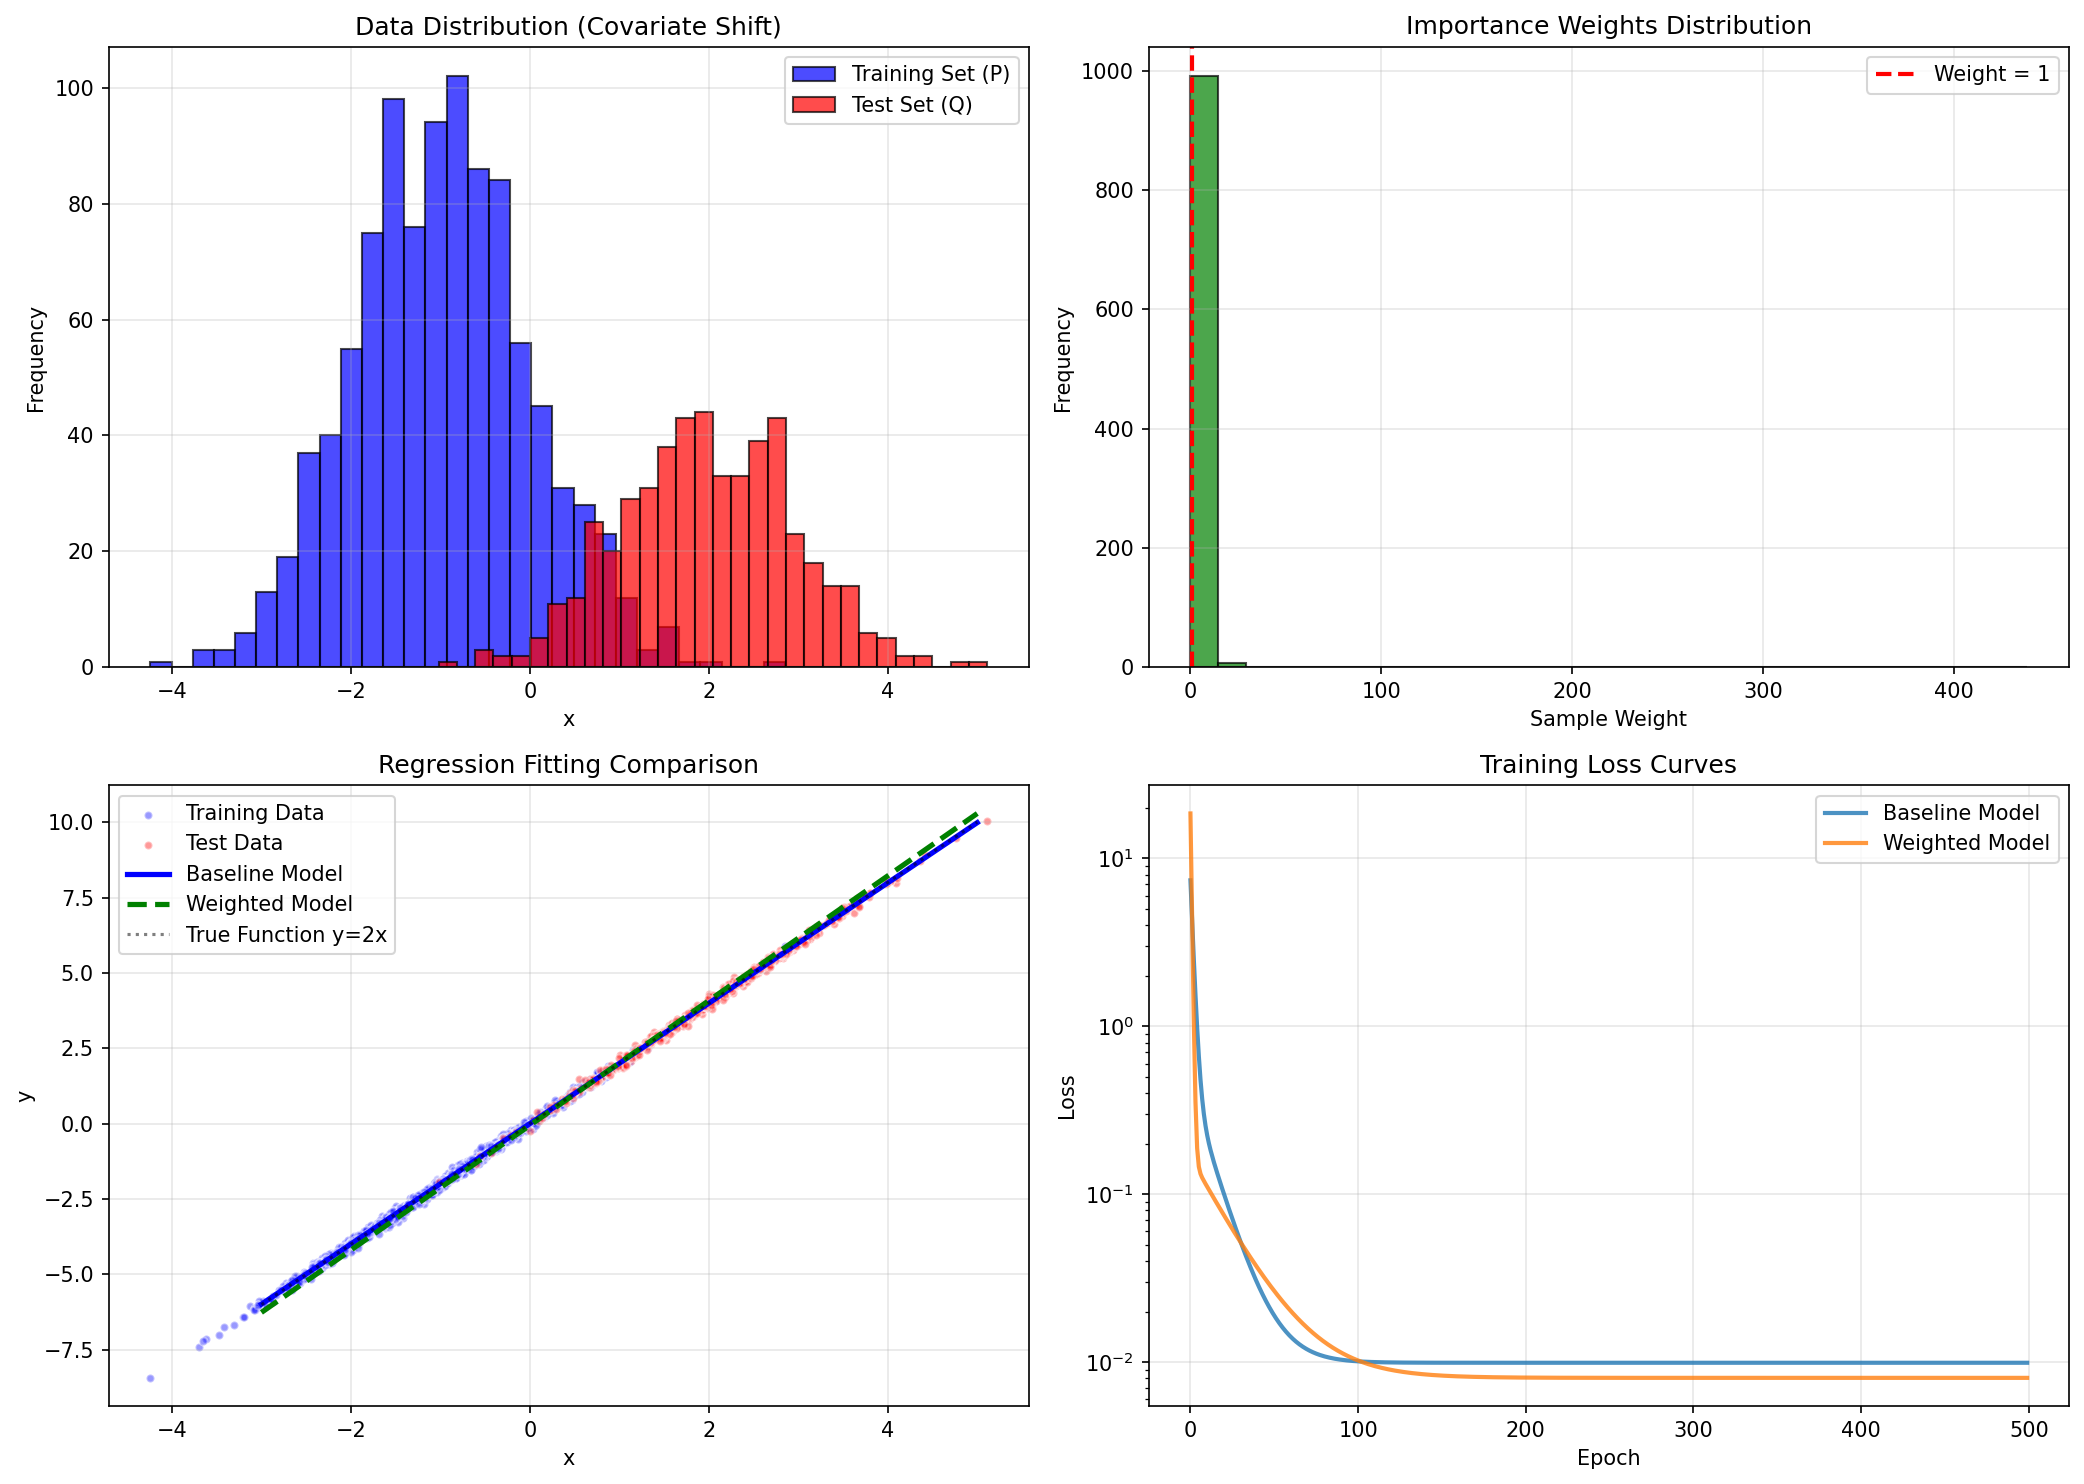